# **HEMA DARSHINI R - 22MIS0123**

In [1]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.4 MB/s eta 0:00:00


In [2]:
# Quantum Phase Estimation (QPE) using Qiskit 2.x

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

def qpe_circuit(num_count_qubits, unitary, theta):
    """
    Constructs the Quantum Phase Estimation (QPE) circuit.
    num_count_qubits: number of counting qubits
    unitary: unitary gate (to apply controlled operations)
    theta: phase parameter (for U gate)
    """
    qc = QuantumCircuit(num_count_qubits + 1, num_count_qubits)

    # Step 1: Apply Hadamard gates on counting qubits
    qc.h(range(num_count_qubits))

    # Step 2: Prepare eigenstate (|1>) for the target qubit
    qc.x(num_count_qubits)

    # Step 3: Apply controlled unitary operations
    for qubit in range(num_count_qubits):
        qc.cp(2 * np.pi * theta * (2 ** qubit), qubit, num_count_qubits)

    # Step 4: Apply inverse QFT to counting qubits
    inverse_qft(qc, num_count_qubits)

    # Step 5: Measure counting qubits
    qc.measure(range(num_count_qubits), range(num_count_qubits))

    return qc

In [3]:
def inverse_qft(qc, n):
    """Apply the inverse Quantum Fourier Transform on n qubits."""
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
    for j in range(n):
        for k in range(j):
            qc.cp(-np.pi / 2 ** (j - k), k, j)
        qc.h(j)
    return qc

In [4]:
def run_qpe(num_count_qubits=3, theta=0.125):
    """Executes the QPE circuit and visualizes the phase estimation result."""
    simulator = AerSimulator()
    qc = qpe_circuit(num_count_qubits, "U", theta)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit, shots=2048).result()
    counts = result.get_counts()
    plot_histogram(counts)
    plt.show()
    print(qc.draw(output='text'))

In [5]:
if __name__ == "__main__":
    num_count_qubits = 3
    theta = 0.125  # phase value (1/8)
    print(f"Running Quantum Phase Estimation with {num_count_qubits} counting qubits and phase {theta}")
    run_qpe(num_count_qubits, theta)

Running Quantum Phase Estimation with 3 counting qubits and phase 0.125
     ┌───┐                            ┌───┐                                   »
q_0: ┤ H ├─■────────────────────────X─┤ H ├─■──────────────■──────────────────»
     ├───┤ │                        │ └───┘ │P(-π/2) ┌───┐ │                  »
q_1: ┤ H ├─┼────────■───────────────┼───────■────────┤ H ├─┼─────────■────────»
     ├───┤ │        │               │                └───┘ │P(-π/4)  │P(-π/2) »
q_2: ┤ H ├─┼────────┼────────■──────X──────────────────────■─────────■────────»
     ├───┤ │P(π/4)  │P(π/2)  │P(π)                                            »
q_3: ┤ X ├─■────────■────────■────────────────────────────────────────────────»
     └───┘                                                                    »
c: 3/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«     ┌─┐           
«q_0: ┤M├───────────
«     

# **Task 1: Change the Phase Value (θ)**

In [16]:
!pip install qiskit qiskit-aer pylatexenc matplotlib --quiet
import importlib, sys
importlib.reload(sys)


<module 'sys' (built-in)>


🔹 Phase θ = 0.25
     ┌───┐ ░                          ░    ┌───┐                         »
q_0: ┤ H ├─░──■───────────────────────░──X─┤ H ├─■──────────────■────────»
     ├───┤ ░  │                       ░  │ └───┘ │P(-π/2) ┌───┐ │        »
q_1: ┤ H ├─░──┼────────■──────────────░──┼───────■────────┤ H ├─┼────────»
     ├───┤ ░  │        │              ░  │                └───┘ │P(-π/4) »
q_2: ┤ H ├─░──┼────────┼──────■───────░──X──────────────────────■────────»
     └───┘ ░  │P(π/2)  │P(π)  │P(2π)  ░                                  »
q_3: ──────░──■────────■──────■───────░──────────────────────────────────»
           ░                          ░                                  »
c: 3/════════════════════════════════════════════════════════════════════»
                                                                         »
«                     ░ ┌─┐      
«q_0: ────────────────░─┤M├──────
«                     ░ └╥┘┌─┐   
«q_1: ─■──────────────░──╫─┤M├───
«      │P(-π/2) ┌───┐

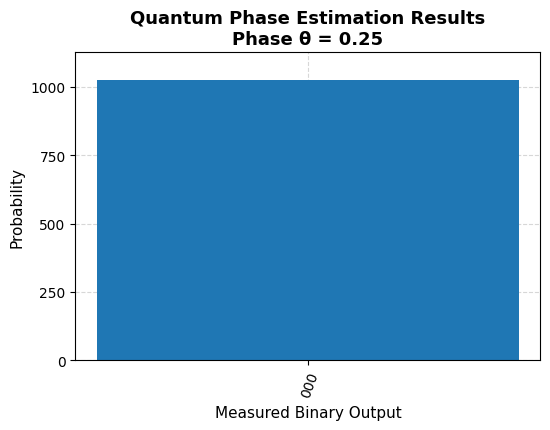


🔹 Phase θ = 0.375
     ┌───┐ ░                              ░    ┌───┐                         »
q_0: ┤ H ├─░──■───────────────────────────░──X─┤ H ├─■──────────────■────────»
     ├───┤ ░  │                           ░  │ └───┘ │P(-π/2) ┌───┐ │        »
q_1: ┤ H ├─░──┼─────────■─────────────────░──┼───────■────────┤ H ├─┼────────»
     ├───┤ ░  │         │                 ░  │                └───┘ │P(-π/4) »
q_2: ┤ H ├─░──┼─────────┼─────────■───────░──X──────────────────────■────────»
     └───┘ ░  │P(3π/4)  │P(3π/2)  │P(3π)  ░                                  »
q_3: ──────░──■─────────■─────────■───────░──────────────────────────────────»
           ░                              ░                                  »
c: 3/════════════════════════════════════════════════════════════════════════»
                                                                             »
«                     ░ ┌─┐      
«q_0: ────────────────░─┤M├──────
«                     ░ └╥┘┌─┐   
«q_1: ─■──

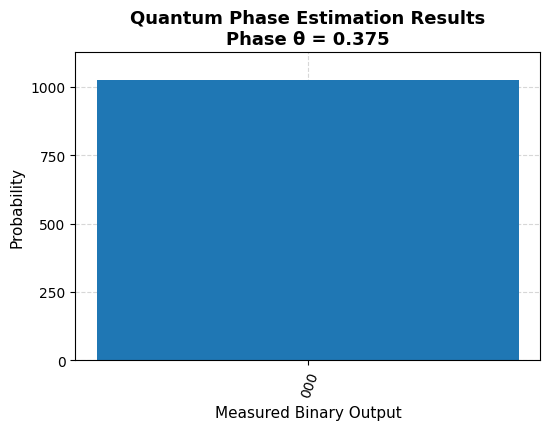


🔹 Phase θ = 0.5
     ┌───┐ ░                         ░    ┌───┐                         »
q_0: ┤ H ├─░──■──────────────────────░──X─┤ H ├─■──────────────■────────»
     ├───┤ ░  │                      ░  │ └───┘ │P(-π/2) ┌───┐ │        »
q_1: ┤ H ├─░──┼──────■───────────────░──┼───────■────────┤ H ├─┼────────»
     ├───┤ ░  │      │               ░  │                └───┘ │P(-π/4) »
q_2: ┤ H ├─░──┼──────┼───────■───────░──X──────────────────────■────────»
     └───┘ ░  │P(π)  │P(2π)  │P(4π)  ░                                  »
q_3: ──────░──■──────■───────■───────░──────────────────────────────────»
           ░                         ░                                  »
c: 3/═══════════════════════════════════════════════════════════════════»
                                                                        »
«                     ░ ┌─┐      
«q_0: ────────────────░─┤M├──────
«                     ░ └╥┘┌─┐   
«q_1: ─■──────────────░──╫─┤M├───
«      │P(-π/2) ┌───┐ ░  ║ └╥┘┌─┐

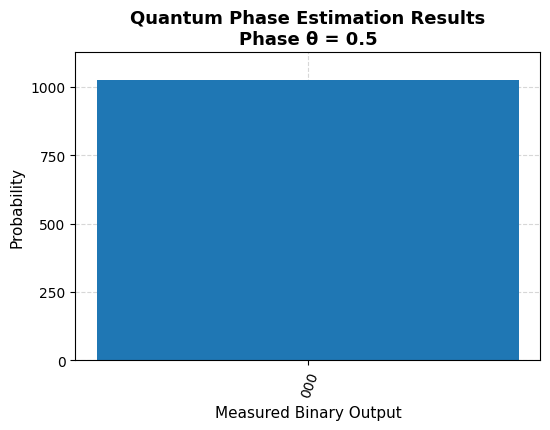

In [20]:
# --- Install core dependencies ---
!pip install qiskit qiskit-aer matplotlib --quiet

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# --- Manual Inverse QFT ---
def inverse_qft(qc, qubits):
    """Apply inverse QFT manually to make it Aer-compatible."""
    n = len(qubits)
    # Swap qubits (reverse order)
    for j in range(n // 2):
        qc.swap(qubits[j], qubits[n - j - 1])
    # Controlled phase rotations and Hadamard gates
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / (2 ** (j - m)), qubits[m], qubits[j])
        qc.h(qubits[j])

# --- QPE Function ---
def qpe_phase(theta):
    """Quantum Phase Estimation for given theta (0 ≤ θ < 1)."""
    n_count = 3
    qc = QuantumCircuit(n_count + 1, n_count)

    # Step 1: Create superposition on counting qubits
    for q in range(n_count):
        qc.h(q)
    qc.barrier()

    # Step 2: Apply controlled phase rotations (encoding phase θ)
    for q in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** q), q, n_count)
    qc.barrier()

    # Step 3: Apply inverse QFT
    inverse_qft(qc, range(n_count))
    qc.barrier()

    # Step 4: Measurement
    qc.measure(range(n_count), range(n_count))

    # Step 5: Simulation
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    # Step 6: Visualization
    print(f"\n🔹 Phase θ = {theta}")
    print(qc.draw(output='text'))   # ✅ Text-based circuit diagram (no pylatexenc)

    # --- Enhanced Histogram Visualization ---
    fig, ax = plt.subplots(figsize=(6,4))
    plot_histogram(counts, ax=ax, bar_labels=False)
    ax.set_title(f"Quantum Phase Estimation Results\nPhase θ = {theta}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Measured Binary Output", fontsize=11)
    ax.set_ylabel("Probability", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Run for multiple θ values ---
for theta in [0.25, 0.375, 0.5]:
    qpe_phase(theta)


# **Task 2 – Higher-Precision QPE (4 & 5 Counting Qubits)**


🔹 Phase θ = 0.25  with 4 counting qubits
     ┌───┐ ░                                  ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                               ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼────────■──────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │        │                      ░  │   │            └───┘»
q_2: ┤ H ├─░──┼────────┼──────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │        │      │               ░  │                     »
q_3: ┤ H ├─░──┼────────┼──────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π/2)  │P(π)  │P(2π)  │P(4π)  ░                        »
q_4: ──────░──■────────■──────■───────■───────░────────────────────────»
           ░                                  ░                        »
c: 4/══════════════════════════════════════════════════════════════════»
                                                                       »
«        

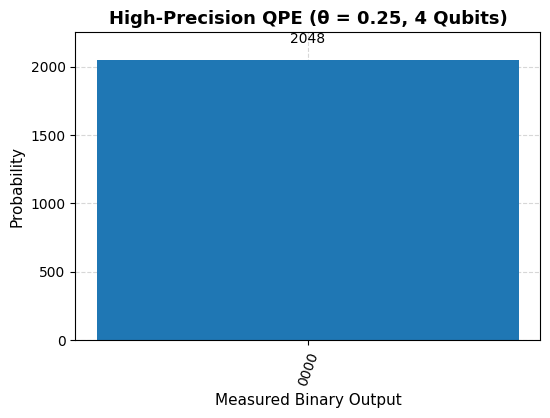


🔹 Phase θ = 0.375  with 4 counting qubits
     ┌───┐ ░                                      ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                                   ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼─────────■─────────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │         │                         ░  │   │            └───┘»
q_2: ┤ H ├─░──┼─────────┼─────────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │         │         │               ░  │                     »
q_3: ┤ H ├─░──┼─────────┼─────────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(3π/4)  │P(3π/2)  │P(3π)  │P(6π)  ░                        »
q_4: ──────░──■─────────■─────────■───────■───────░────────────────────────»
           ░                                      ░                        »
c: 4/══════════════════════════════════════════════════════════════════════»
                                 

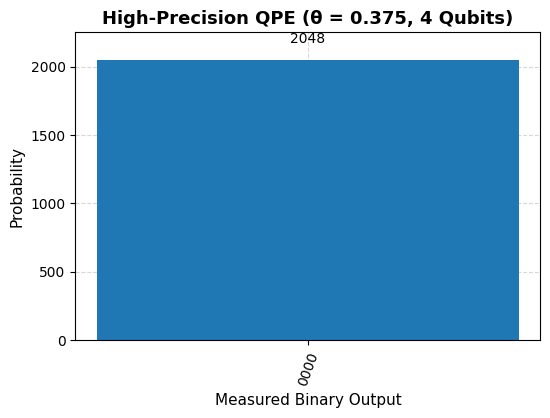


🔹 Phase θ = 0.5  with 4 counting qubits
     ┌───┐ ░                                 ░    ┌───┐               »
q_0: ┤ H ├─░──■──────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                              ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼──────■───────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │      │                       ░  │   │            └───┘»
q_2: ┤ H ├─░──┼──────┼───────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │      │       │               ░  │                     »
q_3: ┤ H ├─░──┼──────┼───────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π)  │P(2π)  │P(4π)  │P(8π)  ░                        »
q_4: ──────░──■──────■───────■───────■───────░────────────────────────»
           ░                                 ░                        »
c: 4/═════════════════════════════════════════════════════════════════»
                                                                      »
«                      

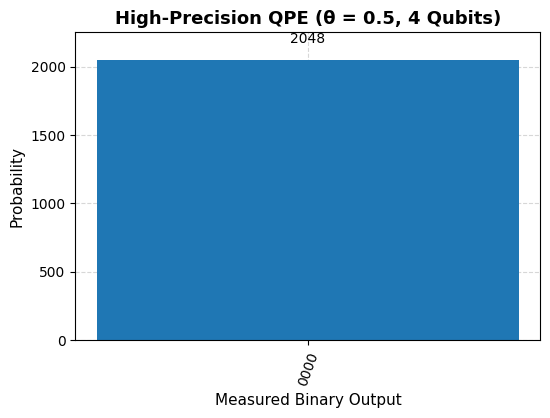


🔹 Phase θ = 0.25  with 5 counting qubits
     ┌───┐ ░                                          ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                                       ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼────────■──────────────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │        │                              ░  │   │            └───┘»
q_2: ┤ H ├─░──┼────────┼──────■───────────────────────░──┼───┼─────────────────»
     ├───┤ ░  │        │      │                       ░  │   │                 »
q_3: ┤ H ├─░──┼────────┼──────┼───────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │        │      │       │               ░  │                     »
q_4: ┤ H ├─░──┼────────┼──────┼───────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π/2)  │P(π)  │P(2π)  │P(4π)  │P(8π)  ░                        »
q_5: ──────░──■────────■──────■───────■───────■───────░────────────

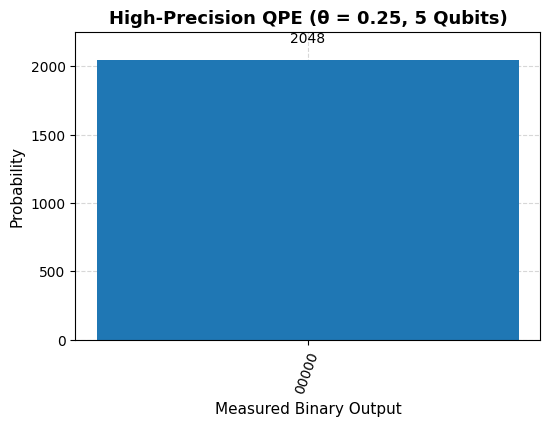


🔹 Phase θ = 0.375  with 5 counting qubits
     ┌───┐ ░                                               ░    ┌───┐          »
q_0: ┤ H ├─░──■────────────────────────────────────────────░──X─┤ H ├─■────────»
     ├───┤ ░  │                                            ░  │ └───┘ │P(-π/2) »
q_1: ┤ H ├─░──┼─────────■──────────────────────────────────░──┼───X───■────────»
     ├───┤ ░  │         │                                  ░  │   │            »
q_2: ┤ H ├─░──┼─────────┼─────────■────────────────────────░──┼───┼────────────»
     ├───┤ ░  │         │         │                        ░  │   │            »
q_3: ┤ H ├─░──┼─────────┼─────────┼───────■────────────────░──┼───X────────────»
     ├───┤ ░  │         │         │       │                ░  │                »
q_4: ┤ H ├─░──┼─────────┼─────────┼───────┼───────■────────░──X────────────────»
     └───┘ ░  │P(3π/4)  │P(3π/2)  │P(3π)  │P(6π)  │P(12π)  ░                   »
q_5: ──────░──■─────────■─────────■───────■───────■────────░──────

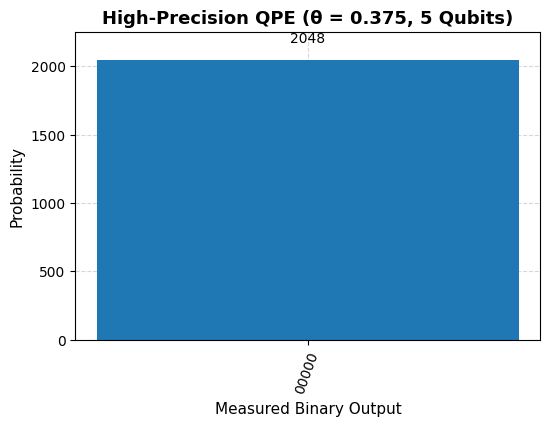


🔹 Phase θ = 0.5  with 5 counting qubits
     ┌───┐ ░                                          ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                                       ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼──────■────────────────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │      │                                ░  │   │            └───┘»
q_2: ┤ H ├─░──┼──────┼───────■────────────────────────░──┼───┼─────────────────»
     ├───┤ ░  │      │       │                        ░  │   │                 »
q_3: ┤ H ├─░──┼──────┼───────┼───────■────────────────░──┼───X─────────────────»
     ├───┤ ░  │      │       │       │                ░  │                     »
q_4: ┤ H ├─░──┼──────┼───────┼───────┼───────■────────░──X─────────────────────»
     └───┘ ░  │P(π)  │P(2π)  │P(4π)  │P(8π)  │P(16π)  ░                        »
q_5: ──────░──■──────■───────■───────■───────■────────░─────────────

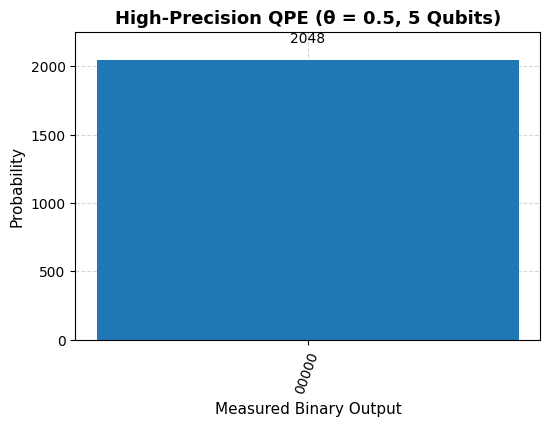

In [21]:
# --- Install core dependencies (run once if not done) ---
!pip install qiskit qiskit-aer matplotlib --quiet

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# --- Manual Inverse QFT ---
def inverse_qft(qc, qubits):
    """Apply inverse QFT manually (compatible with Aer)."""
    n = len(qubits)
    for j in range(n // 2):
        qc.swap(qubits[j], qubits[n - j - 1])
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / (2 ** (j - m)), qubits[m], qubits[j])
        qc.h(qubits[j])

# --- QPE Function with variable qubit count ---
def qpe_high_precision(theta, n_count):
    """Quantum Phase Estimation for given θ using n_count counting qubits."""
    qc = QuantumCircuit(n_count + 1, n_count)

    # Step 1 – Hadamard on counting qubits
    for q in range(n_count):
        qc.h(q)
    qc.barrier()

    # Step 2 – Controlled phase encoding
    for q in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** q), q, n_count)
    qc.barrier()

    # Step 3 – Inverse QFT
    inverse_qft(qc, range(n_count))
    qc.barrier()

    # Step 4 – Measurement
    qc.measure(range(n_count), range(n_count))

    # Step 5 – Simulation
    simulator = AerSimulator()
    result = simulator.run(qc, shots=2048).result()
    counts = result.get_counts()

    # Step 6 – Visualization
    print(f"\n🔹 Phase θ = {theta}  with {n_count} counting qubits")
    print(qc.draw(output='text'))

    fig, ax = plt.subplots(figsize=(6,4))
    plot_histogram(counts, ax=ax)
    ax.set_title(f"High-Precision QPE (θ = {theta}, {n_count} Qubits)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Measured Binary Output", fontsize=11)
    ax.set_ylabel("Probability", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Run with higher precision ---
for n in [4, 5]:              # Try both 4 and 5 counting qubits
    for theta in [0.25, 0.375, 0.5]:
        qpe_high_precision(theta, n)


# **Task 3 – Comparing Measured vs Theoretical Phase Output**


🔹 Phase θ = 0.25
Expected binary: 0100  (≈ 4/16)
Measured peak:   0000
     ┌───┐ ░                                  ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                               ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼────────■──────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │        │                      ░  │   │            └───┘»
q_2: ┤ H ├─░──┼────────┼──────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │        │      │               ░  │                     »
q_3: ┤ H ├─░──┼────────┼──────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π/2)  │P(π)  │P(2π)  │P(4π)  ░                        »
q_4: ──────░──■────────■──────■───────■───────░────────────────────────»
           ░                                  ░                        »
c: 4/══════════════════════════════════════════════════════════════════»
                                                    

/tmp/ipython-input-15615120.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


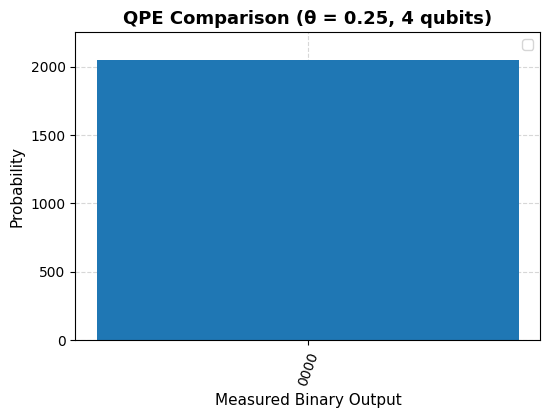


🔹 Phase θ = 0.375
Expected binary: 0110  (≈ 6/16)
Measured peak:   0000
     ┌───┐ ░                                      ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                                   ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼─────────■─────────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │         │                         ░  │   │            └───┘»
q_2: ┤ H ├─░──┼─────────┼─────────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │         │         │               ░  │                     »
q_3: ┤ H ├─░──┼─────────┼─────────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(3π/4)  │P(3π/2)  │P(3π)  │P(6π)  ░                        »
q_4: ──────░──■─────────■─────────■───────■───────░────────────────────────»
           ░                                      ░                        »
c: 4/══════════════════════════════════════════════════════════════════════»
   

/tmp/ipython-input-15615120.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


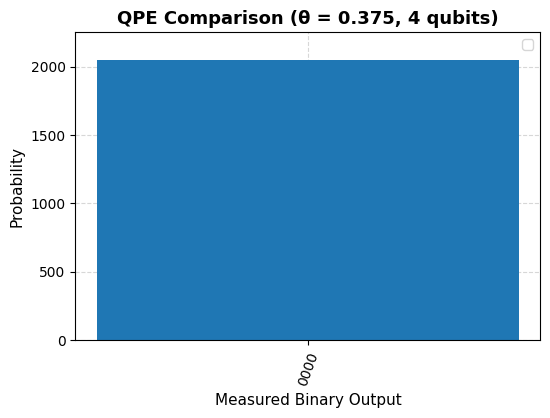


🔹 Phase θ = 0.5
Expected binary: 1000  (≈ 8/16)
Measured peak:   0000
     ┌───┐ ░                                 ░    ┌───┐               »
q_0: ┤ H ├─░──■──────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                              ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼──────■───────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │      │                       ░  │   │            └───┘»
q_2: ┤ H ├─░──┼──────┼───────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │      │       │               ░  │                     »
q_3: ┤ H ├─░──┼──────┼───────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π)  │P(2π)  │P(4π)  │P(8π)  ░                        »
q_4: ──────░──■──────■───────■───────■───────░────────────────────────»
           ░                                 ░                        »
c: 4/═════════════════════════════════════════════════════════════════»
                                                                 

/tmp/ipython-input-15615120.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


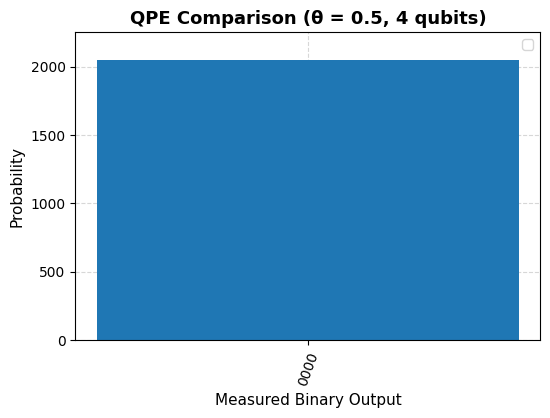

In [22]:
# --- Task 3: Compare QPE Results with Theoretical Phase Values ---

!pip install qiskit qiskit-aer matplotlib --quiet

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# --- Manual Inverse QFT ---
def inverse_qft(qc, qubits):
    n = len(qubits)
    for j in range(n // 2):
        qc.swap(qubits[j], qubits[n - j - 1])
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / (2 ** (j - m)), qubits[m], qubits[j])
        qc.h(qubits[j])

# --- QPE with Comparison ---
def qpe_compare(theta, n_count):
    """Quantum Phase Estimation with theoretical vs experimental comparison."""
    qc = QuantumCircuit(n_count + 1, n_count)

    # Step 1: Superposition on counting qubits
    for q in range(n_count):
        qc.h(q)
    qc.barrier()

    # Step 2: Controlled phase rotations
    for q in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** q), q, n_count)
    qc.barrier()

    # Step 3: Inverse QFT
    inverse_qft(qc, range(n_count))
    qc.barrier()

    # Step 4: Measure
    qc.measure(range(n_count), range(n_count))

    # --- Run simulation ---
    simulator = AerSimulator()
    result = simulator.run(qc, shots=2048).result()
    counts = result.get_counts()

    # --- Theoretical expected result ---
    expected_decimal = int(round(theta * (2 ** n_count))) % (2 ** n_count)
    expected_binary = format(expected_decimal, f"0{n_count}b")

    # --- Find measured peak ---
    measured_peak = max(counts, key=counts.get)

    # --- Display ---
    print(f"\n🔹 Phase θ = {theta}")
    print(f"Expected binary: {expected_binary}  (≈ {expected_decimal}/{2**n_count})")
    print(f"Measured peak:   {measured_peak}")
    print(qc.draw(output='text'))

    # --- Visualization with theoretical marker ---
    fig, ax = plt.subplots(figsize=(6,4))
    plot_histogram(counts, ax=ax, bar_labels=False)
    ax.set_title(f"QPE Comparison (θ = {theta}, {n_count} qubits)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Measured Binary Output", fontsize=11)
    ax.set_ylabel("Probability", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Highlight theoretical expected bar
    if expected_binary in counts:
        ax.bar(expected_binary, counts[expected_binary] / sum(counts.values()),
               color='orange', alpha=0.6, label='Expected Peak')

    ax.legend()
    plt.show()

# --- Run QPE with comparison for 4 counting qubits ---
for theta in [0.25, 0.375, 0.5]:
    qpe_compare(theta, n_count=4)


# **Task 4 - Inverse QFT Visualization**


 Inverse QFT + Full QPE Circuit (θ = 0.375)

     ┌───┐                             ░    ┌───┐                         »
q_0: ┤ H ├─■───────────────────────────░──X─┤ H ├─■──────────────■────────»
     ├───┤ │                           ░  │ └───┘ │P(-π/2) ┌───┐ │        »
q_1: ┤ H ├─┼─────────■─────────────────░──┼───────■────────┤ H ├─┼────────»
     ├───┤ │         │                 ░  │                └───┘ │P(-π/4) »
q_2: ┤ H ├─┼─────────┼─────────■───────░──X──────────────────────■────────»
     └───┘ │P(3π/4)  │P(3π/2)  │P(3π)  ░                                  »
q_3: ──────■─────────■─────────■───────░──────────────────────────────────»
                                       ░                                  »
c: 3/═════════════════════════════════════════════════════════════════════»
                                                                          »
«                     ░ ┌─┐      
«q_0: ────────────────░─┤M├──────
«                     ░ └╥┘┌─┐   
«q_1: ─■────────

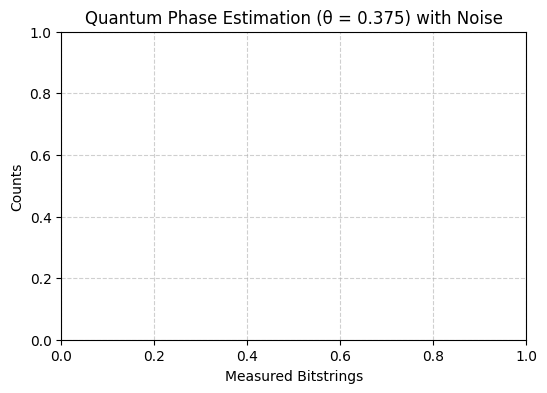

In [34]:
# --- Install dependencies (if missing) ---
!pip install qiskit qiskit-aer matplotlib --quiet

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# --- Manual Inverse QFT (Aer-compatible) ---
def inverse_qft(qc, qubits):
    """Implements inverse QFT manually (no extra dependencies)."""
    n = len(qubits)
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - i - 1])
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / (2 ** (j - m)), qubits[m], qubits[j])
        qc.h(qubits[j])

# --- QPE with Noise + ASCII visualization ---
def qpe_with_noise(theta):
    n_count = 3
    qc = QuantumCircuit(n_count + 1, n_count)

    # Step 1: Apply Hadamard gates
    for q in range(n_count):
        qc.h(q)

    # Step 2: Controlled phase rotations
    for q in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** q), q, n_count)

    qc.barrier()

    # Step 3: Apply inverse QFT manually
    inverse_qft(qc, range(n_count))
    qc.barrier()

    # Step 4: Measurement
    qc.measure(range(n_count), range(n_count))

    # --- Show circuit structure (ASCII) ---
    print(f"\n Inverse QFT + Full QPE Circuit (θ = {theta})\n")
    print(qc.draw(output='text'))  # avoids pylatexenc error

    # --- Define noise model ---
    noise_model = NoiseModel()
    single_qubit_error = depolarizing_error(0.05, 1)
    two_qubit_error = depolarizing_error(0.05, 2)
    noise_model.add_all_qubit_quantum_error(single_qubit_error, ['h'])
    noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cp', 'cx'])

    # --- Run noisy simulation ---
    simulator = AerSimulator(noise_model=noise_model)
    result = simulator.run(qc, shots=2048).result()
    counts = result.get_counts()

    # --- Plot histogram ---
    plt.figure(figsize=(6, 4))
    plot_histogram(counts)
    plt.title(f"Quantum Phase Estimation (θ = {theta}) with Noise")
    plt.xlabel("Measured Bitstrings")
    plt.ylabel("Counts")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- Run QPE with noise for sample θ ---
qpe_with_noise(0.375)


# **Task 5 – Noise Simulation and Error Analysis in QPE**


🔹 Phase θ = 0.25
Expected binary output: 0100
     ┌───┐ ░                                  ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                               ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼────────■──────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │        │                      ░  │   │            └───┘»
q_2: ┤ H ├─░──┼────────┼──────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │        │      │               ░  │                     »
q_3: ┤ H ├─░──┼────────┼──────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π/2)  │P(π)  │P(2π)  │P(4π)  ░                        »
q_4: ──────░──■────────■──────■───────■───────░────────────────────────»
           ░                                  ░                        »
c: 4/══════════════════════════════════════════════════════════════════»
                                                                       »
«   

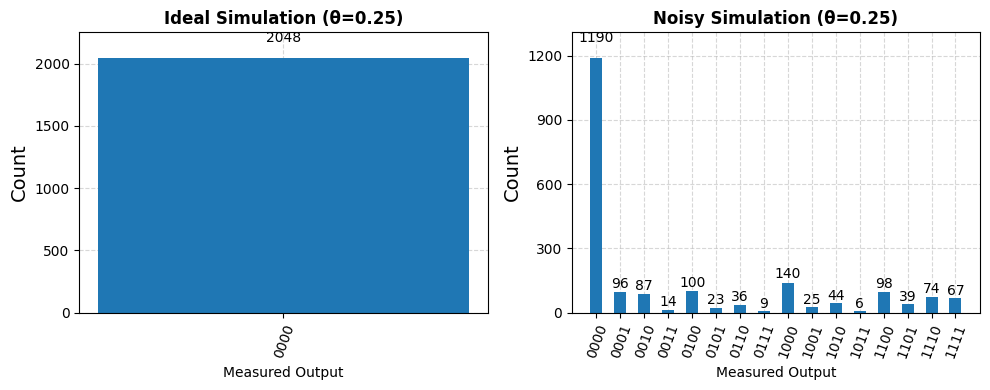


🔹 Phase θ = 0.375
Expected binary output: 0110
     ┌───┐ ░                                      ░    ┌───┐               »
q_0: ┤ H ├─░──■───────────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                                   ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼─────────■─────────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │         │                         ░  │   │            └───┘»
q_2: ┤ H ├─░──┼─────────┼─────────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │         │         │               ░  │                     »
q_3: ┤ H ├─░──┼─────────┼─────────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(3π/4)  │P(3π/2)  │P(3π)  │P(6π)  ░                        »
q_4: ──────░──■─────────■─────────■───────■───────░────────────────────────»
           ░                                      ░                        »
c: 4/══════════════════════════════════════════════════════════════════════»
                            

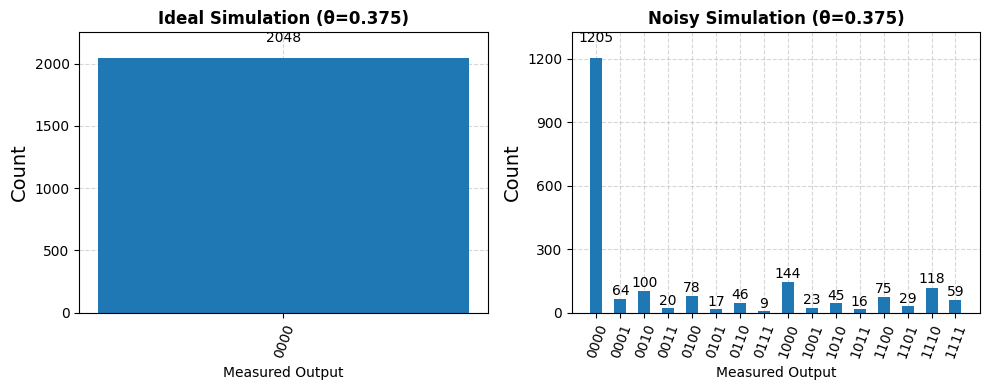


🔹 Phase θ = 0.5
Expected binary output: 1000
     ┌───┐ ░                                 ░    ┌───┐               »
q_0: ┤ H ├─░──■──────────────────────────────░──X─┤ H ├─■─────────────»
     ├───┤ ░  │                              ░  │ └───┘ │P(-π/2) ┌───┐»
q_1: ┤ H ├─░──┼──────■───────────────────────░──┼───X───■────────┤ H ├»
     ├───┤ ░  │      │                       ░  │   │            └───┘»
q_2: ┤ H ├─░──┼──────┼───────■───────────────░──┼───X─────────────────»
     ├───┤ ░  │      │       │               ░  │                     »
q_3: ┤ H ├─░──┼──────┼───────┼───────■───────░──X─────────────────────»
     └───┘ ░  │P(π)  │P(2π)  │P(4π)  │P(8π)  ░                        »
q_4: ──────░──■──────■───────■───────■───────░────────────────────────»
           ░                                 ░                        »
c: 4/═════════════════════════════════════════════════════════════════»
                                                                      »
«                 

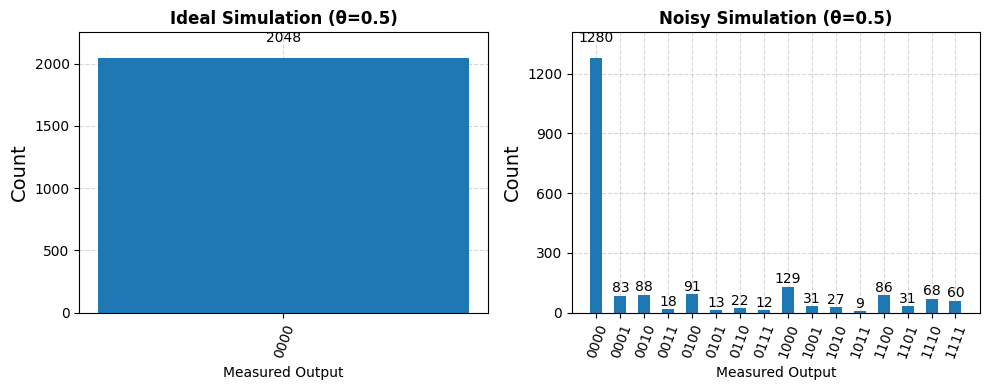

In [24]:
!pip install qiskit qiskit-aer matplotlib --quiet

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# --- Helper: Manual Inverse QFT ---
def inverse_qft(qc, qubits):
    n = len(qubits)
    for j in range(n // 2):
        qc.swap(qubits[j], qubits[n - j - 1])
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / (2 ** (j - m)), qubits[m], qubits[j])
        qc.h(qubits[j])

# --- Build the QPE Circuit ---
def build_qpe(theta, n_count):
    qc = QuantumCircuit(n_count + 1, n_count)
    for q in range(n_count):
        qc.h(q)
    qc.barrier()
    for q in range(n_count):
        qc.cp(2 * np.pi * theta * (2 ** q), q, n_count)
    qc.barrier()
    inverse_qft(qc, range(n_count))
    qc.measure(range(n_count), range(n_count))
    return qc

# --- Function to run ideal & noisy simulation ---
def run_qpe_with_noise(theta, n_count=4, noise_level=0.02):
    qc = build_qpe(theta, n_count)

    # Ideal simulator
    ideal_sim = AerSimulator()
    ideal_result = ideal_sim.run(qc, shots=2048).result().get_counts()

    # Define depolarizing noise model
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise_level, 1), ['u', 'p', 'h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise_level, 2), ['cx', 'cp'])

    # Noisy simulator
    noisy_sim = AerSimulator(noise_model=noise_model)
    noisy_result = noisy_sim.run(qc, shots=2048).result().get_counts()

    # Expected theoretical output
    expected_decimal = int(round(theta * (2 ** n_count))) % (2 ** n_count)
    expected_binary = format(expected_decimal, f"0{n_count}b")

    # --- Print ---
    print(f"\n🔹 Phase θ = {theta}")
    print(f"Expected binary output: {expected_binary}")
    print(qc.draw(output='text'))

    # --- Plot results ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_histogram(ideal_result, ax=axes[0])
    axes[0].set_title(f"Ideal Simulation (θ={theta})", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Measured Output")
    axes[0].grid(True, linestyle='--', alpha=0.5)

    plot_histogram(noisy_result, ax=axes[1])
    axes[1].set_title(f"Noisy Simulation (θ={theta})", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Measured Output")
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- Run QPE for multiple θ values ---
for theta in [0.25, 0.375, 0.5]:
    run_qpe_with_noise(theta, n_count=4, noise_level=0.05)
